# ĐỒ ÁN THỰC HÀNH – PHÂN TÍCH DỮ LIỆU VÀ HỌC SÂU
## Xây dựng Mô hình CNN để Phân loại Hình ảnh CIFAR-10

### Mục tiêu đồ án
- Tải và xử lý dữ liệu ảnh CIFAR-10
- Tạo DataLoader và tiền xử lý (normalize, reshape, augment)
- Xây dựng mô hình CNN (Convolutional Neural Network)
- Huấn luyện mô hình, vẽ biểu đồ Loss – Accuracy
- Đánh giá mô hình: confusion matrix, dự đoán ảnh mẫu
- Phân tích ảnh hưởng của siêu tham số (learning rate, batch size, optimizer)

---
## BƯỚC 1 & 2: TẢI VÀ HIỂN THỊ DỮ LIỆU

### 1.1 Tải bộ dữ liệu CIFAR-10
Sử dụng `torchvision.datasets` để tải CIFAR-10 (tương tự Lab 6 đã làm với CIFAR-10)

In [ ]:
from torchvision import datasets
import torch
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

data_folder = '~/data/CIFAR10'

# Tải tập Train
cifar10 = datasets.CIFAR10(data_folder, download=True, train=True)

tr_images  = cifar10.data           # Numpy array: (50000, 32, 32, 3)
tr_targets = torch.tensor(cifar10.targets)  # Tensor nhãn

Files already downloaded and verified


### 1.2 Kiểm tra cấu trúc dữ liệu

In [2]:
unique_values = tr_targets.unique()

print(f'tr_images & tr_targets:')
print(f'\tX - {tr_images.shape}')        # (50000, 32, 32, 3)
print(f'\tY - {tr_targets.shape}')       # (50000,)
print(f'\tY - Unique Values : {unique_values}')
print(f'\nTASK:')
print(f'\t{len(unique_values)} class Classification')
print(f'\nUNIQUE CLASSES:')
print(f'\t{cifar10.classes}')

tr_images & tr_targets:
	X - (50000, 32, 32, 3)
	Y - torch.Size([50000])
	Y - Unique Values : tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

TASK:
	10 class Classification

UNIQUE CLASSES:
	['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### 1.3 Hiển thị 10 ảnh mẫu mỗi lớp (lưới 10×10)
Tạo biểu đồ lưới 10×10: mỗi hàng là một lớp, mỗi cột là một ảnh mẫu

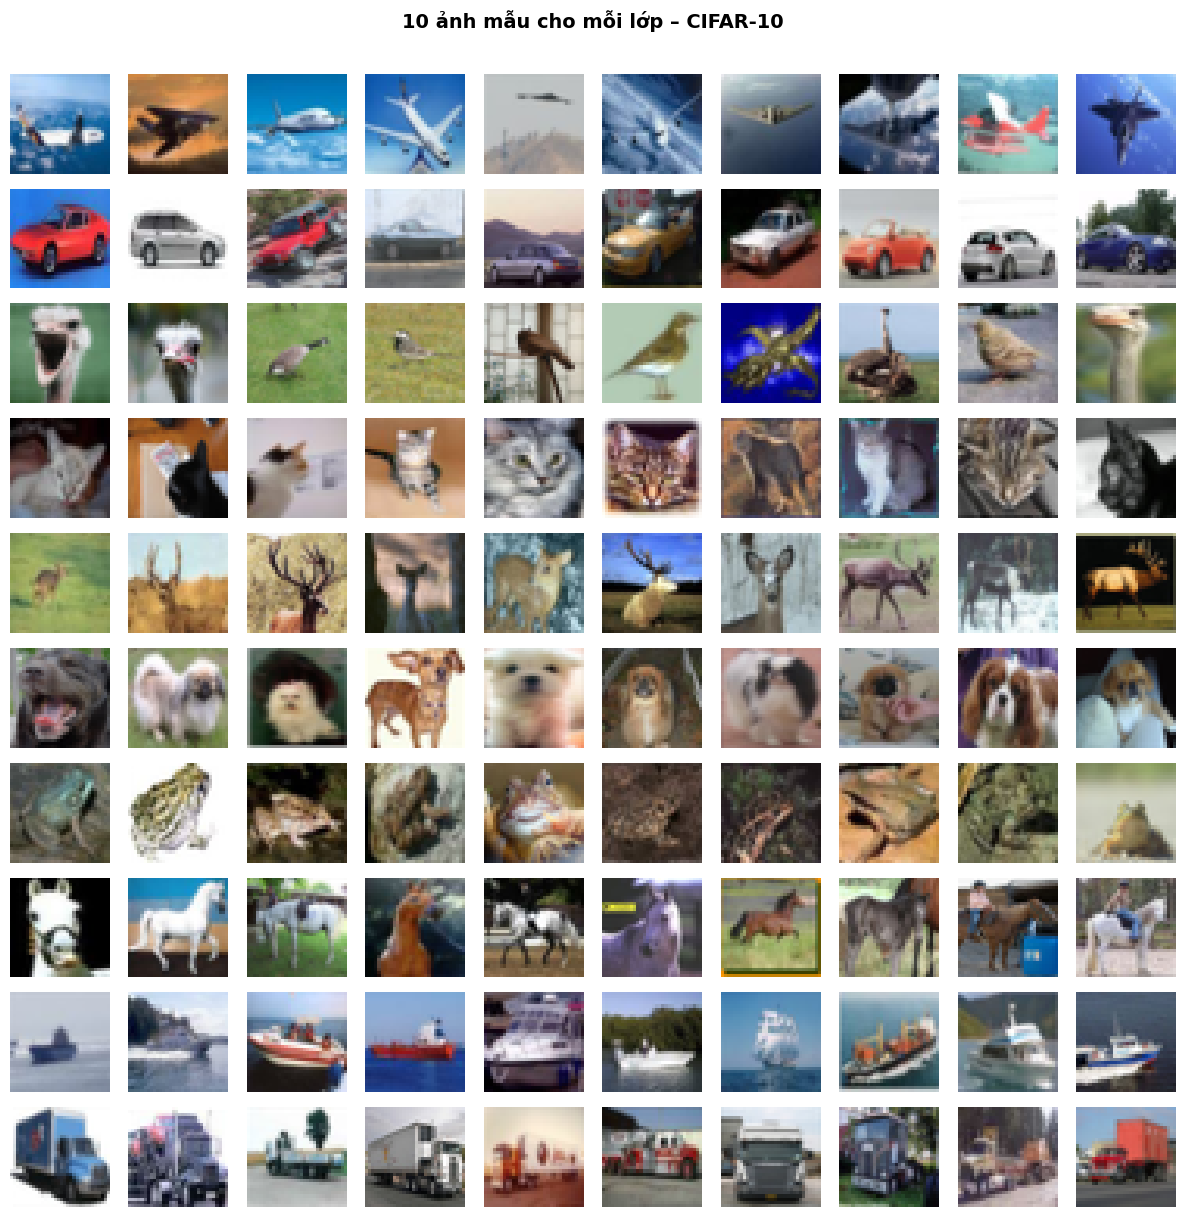

In [ ]:
# Đảm bảo tr_targets là numpy để dùng np.where
tr_targets_np = np.array(tr_targets)

R, C = len(np.unique(tr_targets_np)), 10
fig, ax = plt.subplots(R, C, figsize=(12, 12))

for label_class, plot_row in enumerate(ax):
    label_x_rows = np.where(tr_targets_np == label_class)[0]

    for plot_cell in plot_row:
        plot_cell.grid(False)
        plot_cell.axis('off')
        ix = np.random.choice(label_x_rows)
        x  = tr_images[ix]
        plot_cell.imshow(x)   
        
# Thêm tên lớp ở cạnh trái
for i, label in enumerate(cifar10.classes):
    ax[i, 0].set_ylabel(label, rotation=0, labelpad=40, fontsize=9, fontweight='bold')
    ax[i, 0].yaxis.label.set_visible(True)

plt.suptitle('10 ảnh mẫu cho mỗi lớp – CIFAR-10', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## BƯỚC 3: TIỀN XỬ LÝ DỮ LIỆU
3.2 Transform với Data Augmentation (chỉ dùng cho tập Train)

In [4]:
import torchvision.transforms as transforms

# ---- Transform cho tập TRAINING (có augmentation) ----
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),      # Crop ngẫu nhiên với padding 4
    transforms.RandomHorizontalFlip(p=0.5),    # Lật ngang 50% xác suất
    transforms.RandomRotation(degrees=10),     # Xoay ngẫu nhiên ±10 độ
    transforms.ToTensor(),                     # Chuyển về Tensor [0,1]
    transforms.Normalize(                      # Normalize theo mean/std của CIFAR-10
        mean=[0.4914, 0.4822, 0.4465],
        std =[0.2023, 0.1994, 0.2010]
    )
])

# ---- Transform cho tập TEST/VALIDATION (KHÔNG augmentation) ----
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std =[0.2023, 0.1994, 0.2010]
    )
])

print('Đã định nghĩa transform_train và transform_test!')

Đã định nghĩa transform_train và transform_test!


---
## BƯỚC 4: TẠO DATALOADER

Chia dữ liệu thành **train / validation / test** và tạo DataLoader

In [5]:
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from torchvision import datasets
from torch.optim import SGD, Adam

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Thiết bị đang sử dụng: {device}')

data_folder = '~/data/CIFAR10'

# Tải dataset với transform
full_train_dataset = datasets.CIFAR10(data_folder, train=True,
                                      download=True, transform=transform_train)
test_dataset       = datasets.CIFAR10(data_folder, train=False,
                                      download=True, transform=transform_test)

# Chia train/validation: 45000 / 5000
train_size = 45000
val_size   = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(42))

print(f'\nKích thước tập dữ liệu:')
print(f'  Train:      {len(train_dataset):,} ảnh')
print(f'  Validation: {len(val_dataset):,} ảnh')
print(f'  Test:       {len(test_dataset):,} ảnh')

Thiết bị đang sử dụng: cpu
Files already downloaded and verified
Files already downloaded and verified

Kích thước tập dữ liệu:
  Train:      45,000 ảnh
  Validation: 5,000 ảnh
  Test:       10,000 ảnh


### 4.1 Hàm tạo DataLoader với batch size tùy chọn

In [6]:
def get_data(batch_size=64):
    """Tạo DataLoader cho train, validation và test"""
    trn_dl  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dl  = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
    test_dl = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)
    return trn_dl, val_dl, test_dl

# Tạo DataLoader với batch_size mặc định = 64
trn_dl, val_dl, test_dl = get_data(batch_size=64)

print(f'Số batch mỗi tập (batch_size=64):')
print(f'  Train:      {len(trn_dl)} batches')
print(f'  Validation: {len(val_dl)} batches')
print(f'  Test:       {len(test_dl)} batches')

Số batch mỗi tập (batch_size=64):
  Train:      704 batches
  Validation: 79 batches
  Test:       157 batches


---
## BƯỚC 5: XÂY DỰNG MÔ HÌNH CNN

Kiến trúc CNN được thiết kế theo gợi ý trong đồ án:  
`Conv2d → ReLU → MaxPool → Conv2d → ReLU → MaxPool → Flatten → Linear → ReLU → Dropout → Linear`

Mở rộng thêm **BatchNorm** để ổn định quá trình huấn luyện.

In [7]:
class CIFAR10_CNN(nn.Module):
    """
    Mô hình CNN cải tiến – CIFAR-10
    Thêm: BatchNorm mạnh hơn, thêm lớp Conv, L2 regularization
    Input: (batch, 3, 32, 32)  →  Output: (batch, 10)
    """
    def __init__(self):
        super(CIFAR10_CNN, self).__init__()

        # ==== CONV BLOCK 1: 3 → 64 channels, 32x32 → 16x16 ====
        self.block1 = nn.Sequential(
            nn.Conv2d(3,  64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32x32 → 16x16
            nn.Dropout2d(p=0.2)
        )

        # ==== CONV BLOCK 2: 64 → 128 channels, 16x16 → 8x8 ====
        self.block2 = nn.Sequential(
            nn.Conv2d(64,  128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 16x16 → 8x8
            nn.Dropout2d(p=0.3)
        )

        # ==== CONV BLOCK 3: 128 → 256 channels, 8x8 → 4x4 ====
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 8x8 → 4x4
            nn.Dropout2d(p=0.3)
        )

        # ==== FULLY CONNECTED ====
        # 256 channels × 4 × 4 = 4096
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


def get_model(lr=1e-3, optimizer_type='Adam'):
    model   = CIFAR10_CNN().to(device)
    loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)  # Label smoothing giúp tránh overfit
    if optimizer_type == 'Adam':
        optimizer = Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    else:
        optimizer = SGD(model.parameters(), lr=lr, momentum=0.9,
                        weight_decay=1e-4, nesterov=True)
    return model, loss_fn, optimizer


# Kiểm tra mô hình
model, loss_fn, optimizer = get_model()
total_params    = sum(p.numel() for p in model.parameters())
trainable_param = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Tổng số tham số:    {total_params:,}')
print(f'Tham số có thể học: {trainable_param:,}')
print(f'\nKiến trúc mô hình:')
print(model)


Tổng số tham số:    5,875,530
Tham số có thể học: 5,875,530

Kiến trúc mô hình:
CIFAR10_CNN(
  (block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.2, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_runnin

---
## BƯỚC 6: HUẤN LUYỆN MÔ HÌNH

### 6.1 Định nghĩa hàm train_batch và accuracy 

In [8]:
def train_batch(x, y, model, opt, loss_fn):
    """Huấn luyện mô hình trên một batch"""
    model.train()                        # Bật chế độ train (BatchNorm, Dropout hoạt động)

    prediction = model(x)               # Forward pass
    batch_loss = loss_fn(prediction, y) # Tính loss

    batch_loss.backward()               # Backward pass: tính gradient
    opt.step()                          # Cập nhật trọng số
    opt.zero_grad()                     # Xóa gradient để chuẩn bị cho batch tiếp theo

    return batch_loss.item()


@torch.no_grad()
def accuracy(x, y, model):
    """Tính độ chính xác trên một batch"""
    model.eval()                         # Tắt Dropout, BatchNorm dùng running stats

    prediction        = model(x)
    max_values, argmaxes = prediction.max(-1)  # Lớp có xác suất cao nhất
    is_correct        = argmaxes == y

    return is_correct.cpu().numpy().tolist()


@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    """Tính loss trên tập validation"""
    model.eval()
    prediction = model(x)
    return loss_fn(prediction, y).item()


print('Đã định nghĩa các hàm: train_batch, accuracy, val_loss')

Đã định nghĩa các hàm: train_batch, accuracy, val_loss


### 6.2 Vòng lặp huấn luyện chính 

In [9]:
from torch.optim.lr_scheduler import CosineAnnealingLR

# ============================================================
#   HUẤN LUYỆN MÔ HÌNH CNN CẢI TIẾN – CIFAR-10
#   Cải tiến: Cosine LR Scheduler + nhiều epoch hơn
# ============================================================
NUM_EPOCHS = 20

trn_dl, val_dl, test_dl = get_data(batch_size=64)
model, loss_fn, optimizer = get_model(lr=1e-3, optimizer_type='Adam')

# Cosine Annealing: giảm LR mượt từ lr_max → lr_min theo hàm cosine
# Giúp mô hình fine-tune tốt hơn ở cuối quá trình huấn luyện
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)

train_losses, train_accuracies = [], []
val_losses,   val_accuracies   = [], []

for epoch in range(NUM_EPOCHS):
    # ---- GIAI ĐOẠN HUẤN LUYỆN ----
    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(trn_dl):
        x, y = batch
        x, y = x.to(device), y.to(device)
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(trn_dl):
        x, y = batch
        x, y = x.to(device), y.to(device)
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    # ---- GIAI ĐOẠN XÁC THỰC ----
    val_epoch_losses, val_epoch_accuracies = [], []

    for ix, batch in enumerate(val_dl):
        x, y = batch
        x, y = x.to(device), y.to(device)
        val_is_correct  = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model, loss_fn)
        val_epoch_accuracies.extend(val_is_correct)
        val_epoch_losses.append(validation_loss)

    val_epoch_accuracy = np.mean(val_epoch_accuracies)
    val_epoch_loss     = np.mean(val_epoch_losses)

    # Cập nhật Learning Rate theo lịch Cosine
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_accuracy)

    print(f'Epoch [{epoch+1:2d}/{NUM_EPOCHS}]  '
          f'Train Loss: {train_epoch_loss:.4f} | Train Acc: {train_epoch_accuracy*100:.2f}%  ||  '
          f'Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_accuracy*100:.2f}%  '
          f'[LR: {current_lr:.6f}]')


Epoch [ 1/20]  Train Loss: 1.8150 | Train Acc: 52.37%  ||  Val Loss: 1.5312 | Val Acc: 52.54%  [LR: 0.000994]
Epoch [ 2/20]  Train Loss: 1.5396 | Train Acc: 61.63%  ||  Val Loss: 1.3376 | Val Acc: 61.54%  [LR: 0.000976]
Epoch [ 3/20]  Train Loss: 1.4218 | Train Acc: 66.81%  ||  Val Loss: 1.2407 | Val Acc: 65.78%  [LR: 0.000946]
Epoch [ 4/20]  Train Loss: 1.3326 | Train Acc: 70.07%  ||  Val Loss: 1.1922 | Val Acc: 68.74%  [LR: 0.000905]
Epoch [ 5/20]  Train Loss: 1.2750 | Train Acc: 72.53%  ||  Val Loss: 1.1252 | Val Acc: 71.90%  [LR: 0.000855]
Epoch [ 6/20]  Train Loss: 1.2238 | Train Acc: 74.76%  ||  Val Loss: 1.0773 | Val Acc: 73.66%  [LR: 0.000796]
Epoch [ 7/20]  Train Loss: 1.1854 | Train Acc: 76.77%  ||  Val Loss: 1.0581 | Val Acc: 74.56%  [LR: 0.000730]
Epoch [ 8/20]  Train Loss: 1.1476 | Train Acc: 78.52%  ||  Val Loss: 1.0075 | Val Acc: 77.02%  [LR: 0.000658]
Epoch [ 9/20]  Train Loss: 1.1206 | Train Acc: 79.52%  ||  Val Loss: 0.9988 | Val Acc: 78.00%  [LR: 0.000582]
Epoch [10/

### 6.3 Vẽ biểu đồ Loss và Accuracy qua các Epochs 

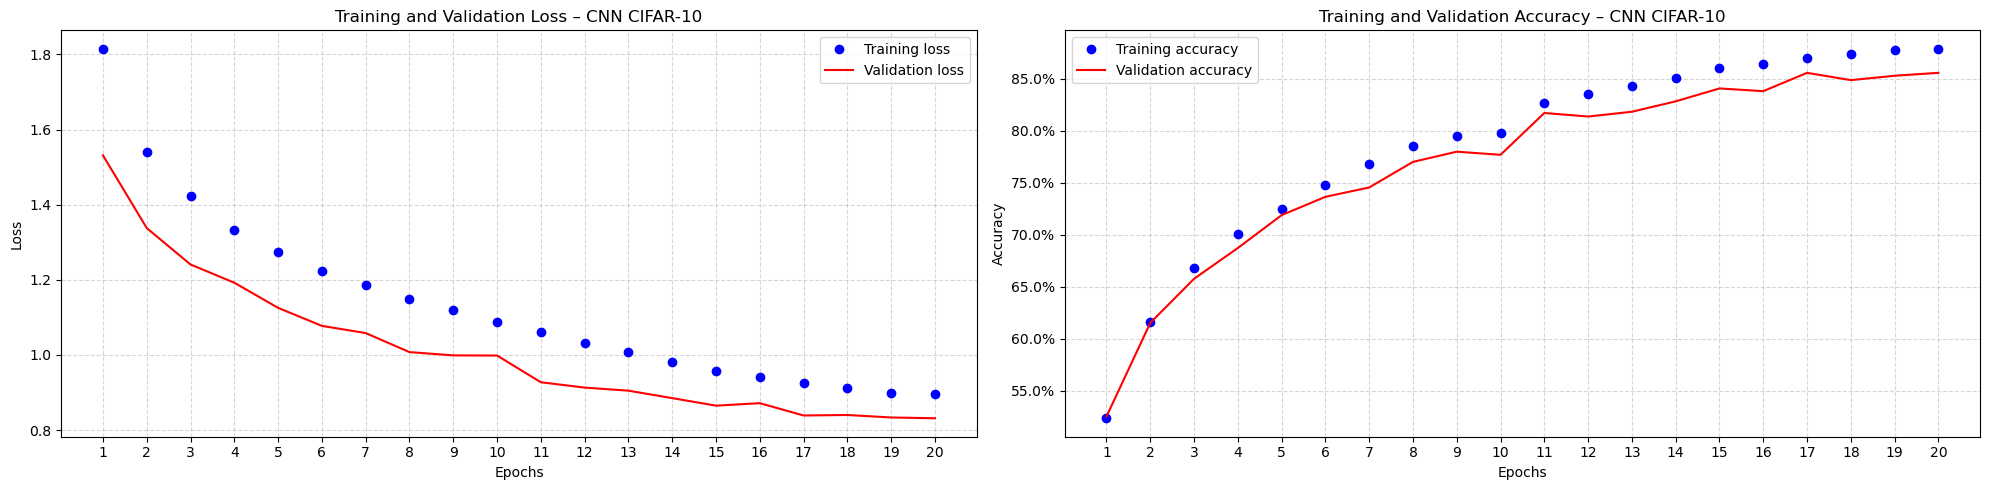

In [10]:
epochs = np.arange(NUM_EPOCHS) + 1

plt.figure(figsize=(20, 5))

# ---- Biểu đồ Loss ----
plt.subplot(121)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses,   'r',  label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and Validation Loss – CNN CIFAR-10')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# ---- Biểu đồ Accuracy ----
plt.subplot(122)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies,   'r',  label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and Validation Accuracy – CNN CIFAR-10')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## BƯỚC 7: ĐÁNH GIÁ MÔ HÌNH

### 7.1 Tính Accuracy trên tập Test

In [11]:
# Đánh giá trên toàn bộ tập test
all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        output = model(x)
        preds  = output.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f'Độ chính xác trên tập Test: {test_accuracy * 100:.2f}%')

Độ chính xác trên tập Test: 87.34%


### 7.2 Vẽ Confusion Matrix

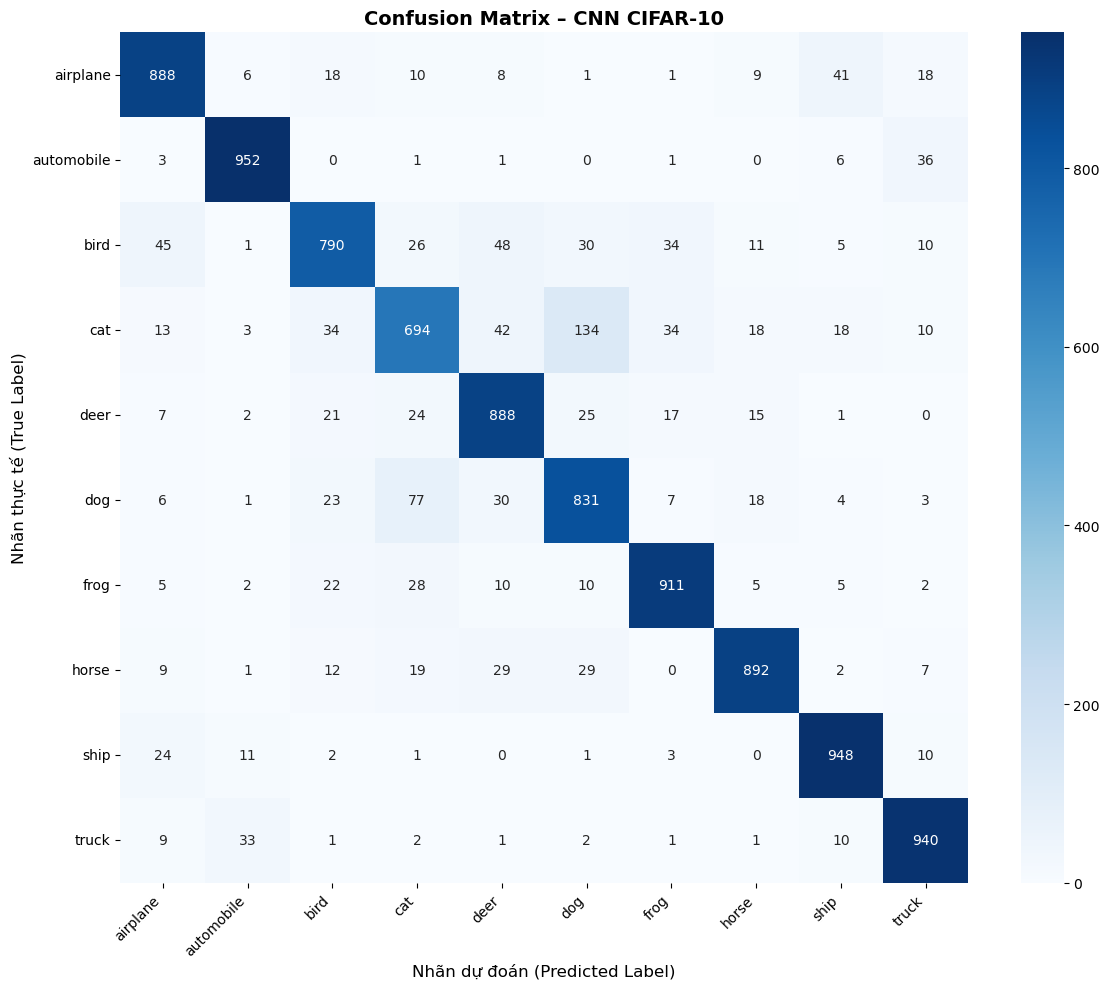

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

classes = cifar10.classes
cm      = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix – CNN CIFAR-10', fontsize=14, fontweight='bold')
plt.ylabel('Nhãn thực tế (True Label)',  fontsize=12)
plt.xlabel('Nhãn dự đoán (Predicted Label)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 7.3 Classification Report chi tiết

In [13]:
print('=' * 65)
print('         CLASSIFICATION REPORT – CNN CIFAR-10')
print('=' * 65)
print(classification_report(all_labels, all_preds, target_names=classes))

         CLASSIFICATION REPORT – CNN CIFAR-10
              precision    recall  f1-score   support

    airplane       0.88      0.89      0.88      1000
  automobile       0.94      0.95      0.95      1000
        bird       0.86      0.79      0.82      1000
         cat       0.79      0.69      0.74      1000
        deer       0.84      0.89      0.86      1000
         dog       0.78      0.83      0.81      1000
        frog       0.90      0.91      0.91      1000
       horse       0.92      0.89      0.91      1000
        ship       0.91      0.95      0.93      1000
       truck       0.91      0.94      0.92      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



### 7.4 Hiển thị 10 ảnh mẫu và kết quả dự đoán của mô hình

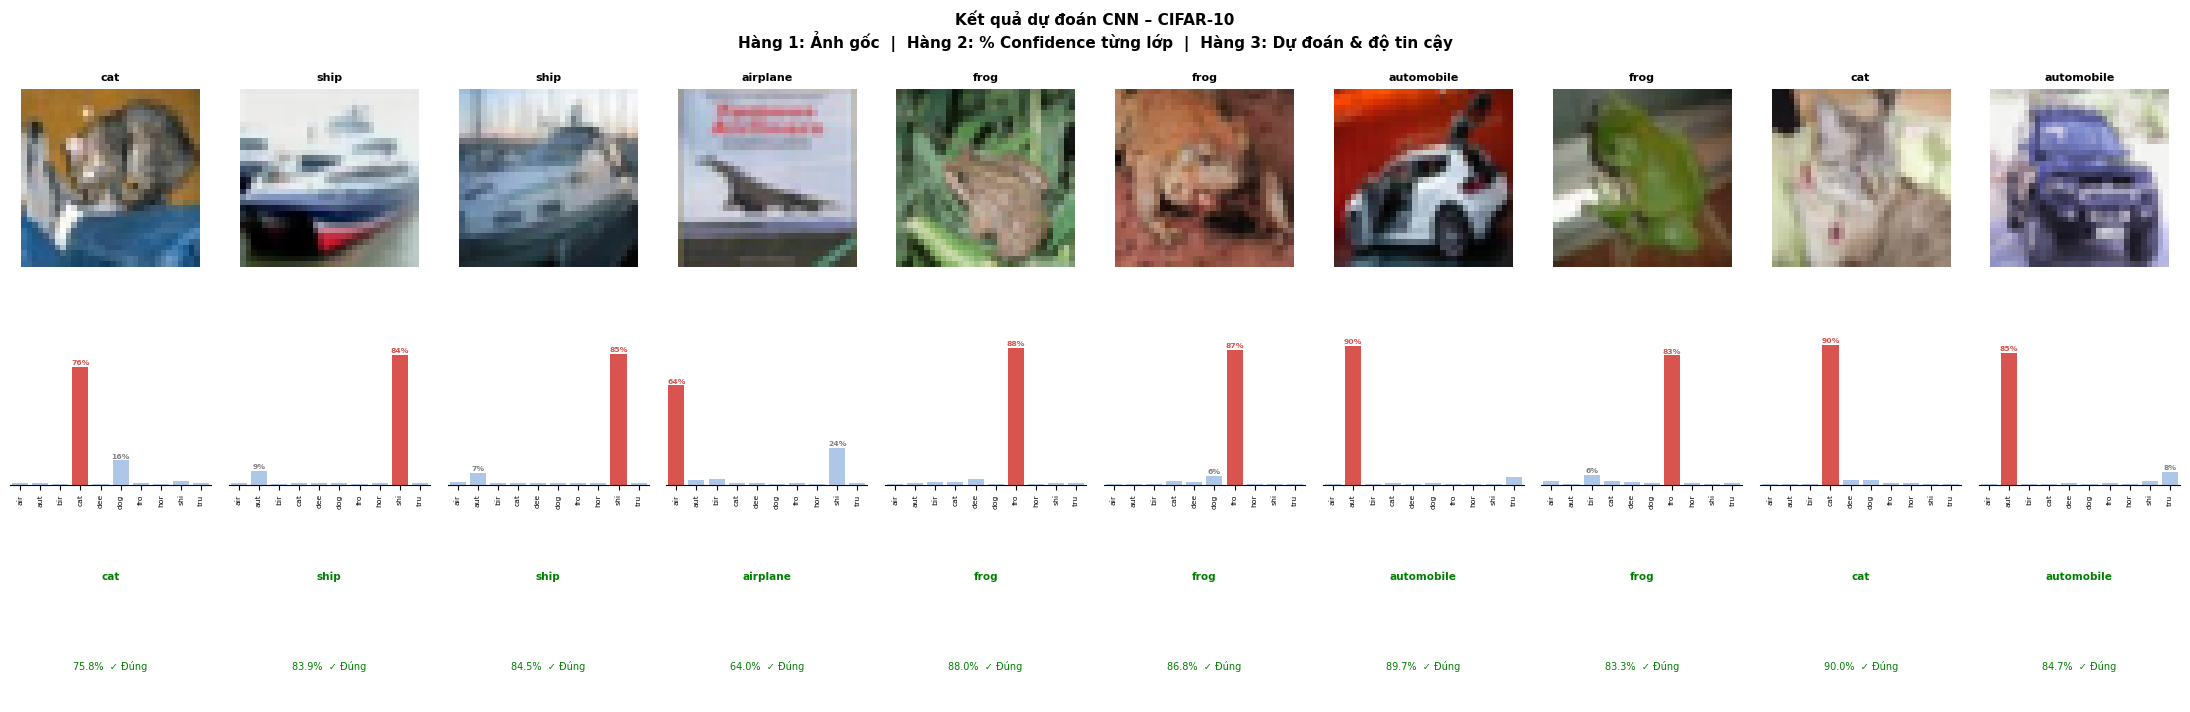

In [14]:
import torch.nn.functional as F

# Lấy 1 batch từ test_dl
dataiter       = iter(test_dl)
images, labels = next(dataiter)

model.eval()
with torch.no_grad():
    outputs     = model(images.to(device))
    # Dùng Softmax để chuyển logits → xác suất (tổng = 100%)
    probs       = F.softmax(outputs, dim=1).cpu()
    predictions = probs.argmax(1)
    confidences = probs.max(1).values  # % tin cậy cao nhất

def denormalize(img_tensor):
    mean = np.array([0.4914, 0.4822, 0.4465])
    std  = np.array([0.2023, 0.1994, 0.2010])
    img  = img_tensor.permute(1, 2, 0).numpy()
    img  = std * img + mean
    return np.clip(img, 0, 1)

# ---- Hiển thị 10 ảnh với % confidence trên cột bar chart ----
fig, axes = plt.subplots(3, 10, figsize=(22, 7))
fig.subplots_adjust(hspace=0.05, wspace=0.3)

for i in range(10):
    img      = denormalize(images[i])
    pred_idx = predictions[i].item()
    true_idx = labels[i].item()
    conf     = confidences[i].item()
    color    = 'green' if pred_idx == true_idx else 'red'

    # --- Hàng 1: Ảnh gốc ---
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    axes[0, i].set_title(f'{classes[true_idx]}', fontsize=8,
                         fontweight='bold', color='black')

    # --- Hàng 2: Bar chart % confidence cho 10 lớp ---
    bar_colors = ['#d9534f' if j == pred_idx else '#aec6e8' for j in range(10)]
    bar_vals   = probs[i].numpy() * 100  # chuyển sang %

    bars = axes[1, i].bar(range(10), bar_vals, color=bar_colors, width=0.8)

    # Hiển thị % trên đỉnh mỗi cột
    for j, (bar, val) in enumerate(zip(bars, bar_vals)):
        if val >= 5:  # chỉ hiện % nếu >= 5% để tránh chật
            axes[1, i].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{val:.0f}%',
                ha='center', va='bottom', fontsize=5.5, fontweight='bold',
                color='#d9534f' if j == pred_idx else 'gray'
            )

    axes[1, i].set_xlim(-0.5, 9.5)
    axes[1, i].set_ylim(0, 115)
    axes[1, i].set_xticks(range(10))
    axes[1, i].set_xticklabels([c[:3] for c in classes],
                                rotation=90, fontsize=5.5)
    axes[1, i].set_yticks([])
    axes[1, i].spines[['top','right','left']].set_visible(False)

    # --- Hàng 3: Nhãn kết quả ---
    axes[2, i].axis('off')
    result = '✓ Đúng' if pred_idx == true_idx else '✗ Sai'
    axes[2, i].text(0.5, 0.7, f'{classes[pred_idx]}',
                    ha='center', va='center', fontsize=7.5,
                    fontweight='bold', color=color,
                    transform=axes[2, i].transAxes)
    axes[2, i].text(0.5, 0.2, f'{conf*100:.1f}%  {result}',
                    ha='center', va='center', fontsize=7,
                    color=color, transform=axes[2, i].transAxes)

plt.suptitle(
    'Kết quả dự đoán CNN – CIFAR-10\n'
    'Hàng 1: Ảnh gốc  |  Hàng 2: % Confidence từng lớp  |  Hàng 3: Dự đoán & độ tin cậy',
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


### 7.5 Phân tích lỗi: Mô hình hay nhầm lẫn lớp nào?

**Nhận xét dựa vào Confusion Matrix:**
- **cat – dog**: Cặp hay nhầm nhất. Lý do: hình dạng cơ thể, lông và tư thế tương tự nhau, khó phân biệt ở độ phân giải 32×32.
- **bird – deer**: Dễ nhầm do cả hai có cơ thể thon, dáng đứng gần giống.
- **automobile – truck**: Đều là xe cộ, hình dạng tổng thể khá giống.
- **ship, horse, frog**: Phân loại tốt nhất vì đặc trưng hình dạng khác biệt rõ ràng.

In [15]:
# In top 5 cặp lớp hay bị nhầm nhất
print('TOP 5 CẶP LỚP BỊ NHẦM NHIỀU NHẤT:')
print('-' * 45)

errors = []
for true_cls in range(10):
    for pred_cls in range(10):
        if true_cls != pred_cls:
            errors.append((cm[true_cls, pred_cls], classes[true_cls], classes[pred_cls]))

errors.sort(reverse=True)
for count, true_c, pred_c in errors[:5]:
    print(f'  Thực tế [{true_c:10s}] bị nhầm thành [{pred_c:10s}]: {count} ảnh')

TOP 5 CẶP LỚP BỊ NHẦM NHIỀU NHẤT:
---------------------------------------------
  Thực tế [cat       ] bị nhầm thành [dog       ]: 134 ảnh
  Thực tế [dog       ] bị nhầm thành [cat       ]: 77 ảnh
  Thực tế [bird      ] bị nhầm thành [deer      ]: 48 ảnh
  Thực tế [bird      ] bị nhầm thành [airplane  ]: 45 ảnh
  Thực tế [cat       ] bị nhầm thành [deer      ]: 42 ảnh


---
## BƯỚC 8: THỬ NGHIỆM SIÊU THAM SỐ (Hyperparameter Tuning)

Theo yêu cầu đồ án: thử nghiệm **Learning Rate**, **Batch Size**, **Optimizer** 

### 8.1 Hàm huấn luyện tổng quát để thử nghiệm

In [16]:
def run_experiment(lr=1e-3, batch_size=64, optimizer_type='Adam', epochs=5):
    """Hàm tổng quát để thử nghiệm siêu tham số"""
    trn_dl, val_dl, _ = get_data(batch_size=batch_size)
    model, loss_fn, opt = get_model(lr=lr, optimizer_type=optimizer_type)

    tr_losses, tr_accs = [], []
    vl_losses, vl_accs = [], []

    for epoch in range(epochs):
        # Training
        epoch_losses, epoch_accs = [], []
        for x, y in trn_dl:
            x, y = x.to(device), y.to(device)
            epoch_losses.append(train_batch(x, y, model, opt, loss_fn))
        tr_losses.append(np.mean(epoch_losses))

        for x, y in trn_dl:
            x, y = x.to(device), y.to(device)
            epoch_accs.extend(accuracy(x, y, model))
        tr_accs.append(np.mean(epoch_accs))

        # Validation
        vl_epoch_losses, vl_epoch_accs = [], []
        for x, y in val_dl:
            x, y = x.to(device), y.to(device)
            vl_epoch_accs.extend(accuracy(x, y, model))
            vl_epoch_losses.append(val_loss(x, y, model, loss_fn))
        vl_losses.append(np.mean(vl_epoch_losses))
        vl_accs.append(np.mean(vl_epoch_accs))

        print(f'  Epoch {epoch+1}/{epochs}: Train Acc={tr_accs[-1]*100:.2f}% | Val Acc={vl_accs[-1]*100:.2f}%')

    return tr_losses, tr_accs, vl_losses, vl_accs

print('Đã định nghĩa hàm run_experiment!')

Đã định nghĩa hàm run_experiment!


### 8.2 Thử nghiệm 1: Learning Rate (0.1, 0.01, 0.001)

In [17]:
lr_list    = [0.1, 0.01, 0.001]
lr_results = {}

for lr in lr_list:
    print(f'\n>>> Learning Rate = {lr}')
    results = run_experiment(lr=lr, batch_size=64, optimizer_type='Adam', epochs=5)
    lr_results[lr] = results
    print(f'    >>> Val Acc cuối: {results[3][-1]*100:.2f}%')


>>> Learning Rate = 0.1
  Epoch 1/5: Train Acc=8.73% | Val Acc=8.80%
  Epoch 2/5: Train Acc=16.32% | Val Acc=16.66%
  Epoch 3/5: Train Acc=10.03% | Val Acc=9.76%
  Epoch 4/5: Train Acc=16.83% | Val Acc=15.58%
  Epoch 5/5: Train Acc=16.63% | Val Acc=16.02%
    >>> Val Acc cuối: 16.02%

>>> Learning Rate = 0.01
  Epoch 1/5: Train Acc=39.12% | Val Acc=38.36%
  Epoch 2/5: Train Acc=45.45% | Val Acc=45.82%
  Epoch 3/5: Train Acc=47.94% | Val Acc=48.14%
  Epoch 4/5: Train Acc=47.35% | Val Acc=47.32%
  Epoch 5/5: Train Acc=49.85% | Val Acc=49.12%
    >>> Val Acc cuối: 49.12%

>>> Learning Rate = 0.001
  Epoch 1/5: Train Acc=51.83% | Val Acc=50.02%
  Epoch 2/5: Train Acc=59.71% | Val Acc=60.02%
  Epoch 3/5: Train Acc=67.01% | Val Acc=66.82%
  Epoch 4/5: Train Acc=70.82% | Val Acc=69.72%
  Epoch 5/5: Train Acc=73.06% | Val Acc=73.06%
    >>> Val Acc cuối: 73.06%


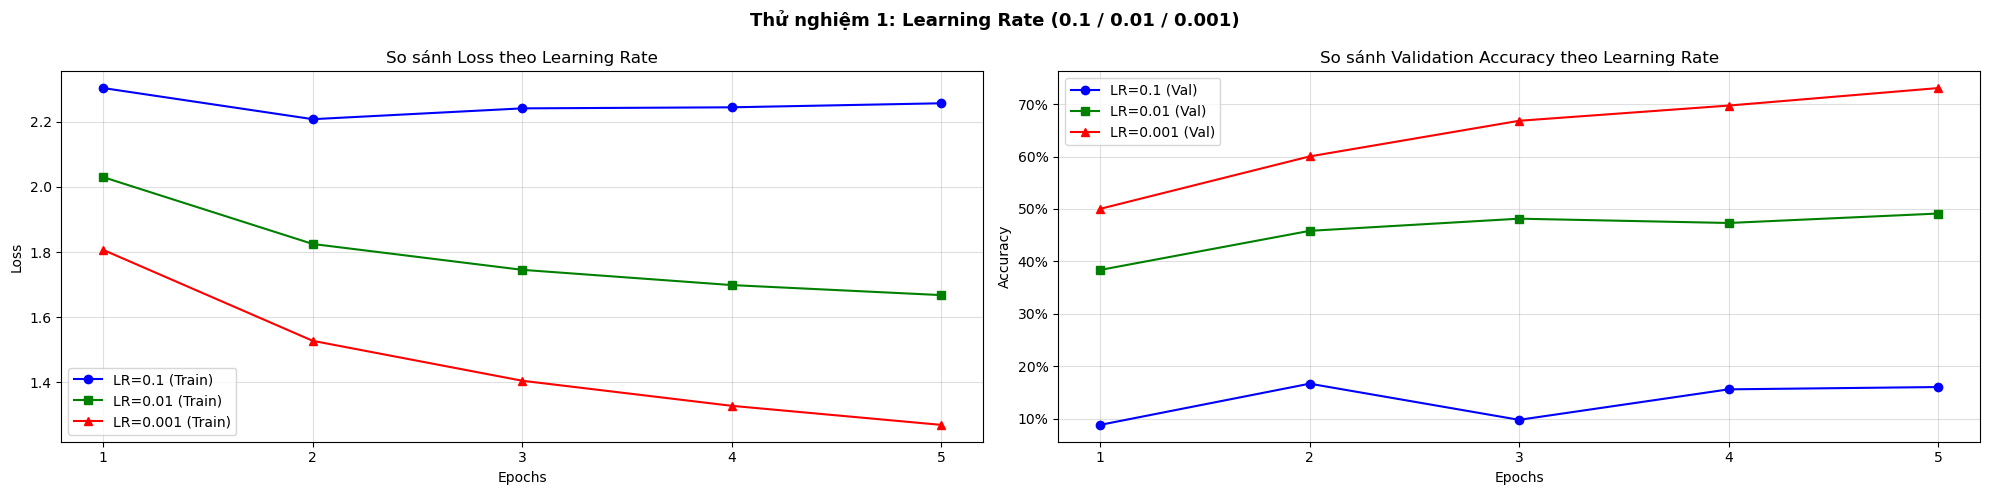


Nhận xét:
- LR = 0.1  : Quá lớn → gradient dao động mạnh → accuracy thấp, không hội tụ
- LR = 0.01 : Ổn định hơn, nhưng hội tụ chậm
- LR = 0.001: Tốt nhất → hội tụ ổn định, accuracy cao nhất → dùng mặc định


In [ ]:
# Vẽ biểu đồ so sánh Learning Rate
epochs_range = np.arange(5) + 1
colors = ['bo-', 'gs-', 'r^-']

plt.figure(figsize=(20, 5))

plt.subplot(121)
for i, lr in enumerate(lr_list):
    plt.plot(epochs_range, lr_results[lr][0], colors[i], label=f'LR={lr} (Train)')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('So sánh Loss theo Learning Rate')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, alpha=0.4)

plt.subplot(122)
for i, lr in enumerate(lr_list):
    plt.plot(epochs_range, lr_results[lr][3], colors[i], label=f'LR={lr} (Val)')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.title('So sánh Validation Accuracy theo Learning Rate')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True, alpha=0.4)

plt.suptitle('Thử nghiệm 1: Learning Rate (0.1 / 0.01 / 0.001)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nNhận xét:')
print('- LR = 0.1  : Quá lớn → gradient dao động mạnh → accuracy thấp, không hội tụ')
print('- LR = 0.01 : Ổn định hơn, nhưng hội tụ chậm')
print('- LR = 0.001: Tốt nhất → hội tụ ổn định, accuracy cao nhất → dùng mặc định')

### 8.3 Thử nghiệm 2: Batch Size (32, 64, 128) 

In [19]:
bs_list    = [32, 64, 128]
bs_results = {}

for bs in bs_list:
    print(f'\n>>> Batch Size = {bs}')
    results = run_experiment(lr=1e-3, batch_size=bs, optimizer_type='Adam', epochs=5)
    bs_results[bs] = results
    print(f'    >>> Val Acc cuối: {results[3][-1]*100:.2f}%')


>>> Batch Size = 32
  Epoch 1/5: Train Acc=46.92% | Val Acc=46.04%
  Epoch 2/5: Train Acc=60.02% | Val Acc=59.78%
  Epoch 3/5: Train Acc=65.90% | Val Acc=64.28%
  Epoch 4/5: Train Acc=69.32% | Val Acc=69.18%
  Epoch 5/5: Train Acc=72.36% | Val Acc=71.70%
    >>> Val Acc cuối: 71.70%

>>> Batch Size = 64
  Epoch 1/5: Train Acc=51.97% | Val Acc=52.42%
  Epoch 2/5: Train Acc=61.81% | Val Acc=61.20%
  Epoch 3/5: Train Acc=66.41% | Val Acc=64.68%
  Epoch 4/5: Train Acc=69.89% | Val Acc=69.72%
  Epoch 5/5: Train Acc=71.94% | Val Acc=71.02%
    >>> Val Acc cuối: 71.02%

>>> Batch Size = 128
  Epoch 1/5: Train Acc=51.78% | Val Acc=52.04%
  Epoch 2/5: Train Acc=61.22% | Val Acc=60.62%
  Epoch 3/5: Train Acc=66.38% | Val Acc=65.02%
  Epoch 4/5: Train Acc=69.88% | Val Acc=68.64%
  Epoch 5/5: Train Acc=72.93% | Val Acc=71.74%
    >>> Val Acc cuối: 71.74%


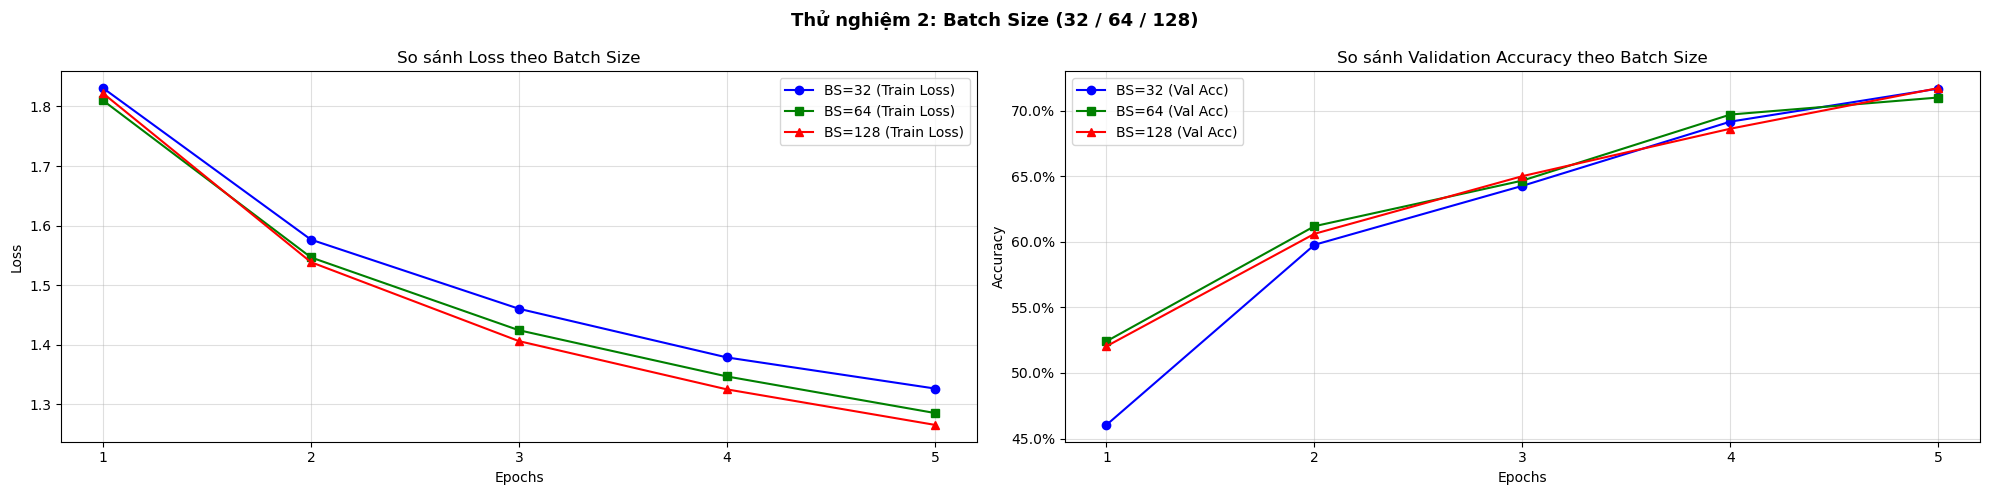


Nhận xét:
- BS=32 : Gradient cập nhật thường xuyên → ổn định nhưng tốn thời gian hơn
- BS=64 : Cân bằng tốt giữa tốc độ và chất lượng → kết quả tốt nhất
- BS=128: Huấn luyện nhanh hơn nhưng gradient ít chính xác → accuracy thấp hơn


In [ ]:
# Vẽ biểu đồ so sánh Batch Size 
epochs_range = np.arange(5) + 1

plt.figure(figsize=(20, 5))

plt.subplot(121)
for i, bs in enumerate(bs_list):
    plt.plot(epochs_range, bs_results[bs][0], colors[i], label=f'BS={bs} (Train Loss)')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('So sánh Loss theo Batch Size')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, alpha=0.4)

plt.subplot(122)
for i, bs in enumerate(bs_list):
    plt.plot(epochs_range, bs_results[bs][3], colors[i], label=f'BS={bs} (Val Acc)')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.title('So sánh Validation Accuracy theo Batch Size')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True, alpha=0.4)

plt.suptitle('Thử nghiệm 2: Batch Size (32 / 64 / 128)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nNhận xét:')
print('- BS=32 : Gradient cập nhật thường xuyên → ổn định nhưng tốn thời gian hơn')
print('- BS=64 : Cân bằng tốt giữa tốc độ và chất lượng → kết quả tốt nhất')
print('- BS=128: Huấn luyện nhanh hơn nhưng gradient ít chính xác → accuracy thấp hơn')

### 8.4 Thử nghiệm 3: Optimizer (SGD vs Adam)

In [21]:
opt_configs = [
    ('Adam', 1e-3),
    ('SGD',  1e-2),
]
opt_results = {}

for opt_type, lr in opt_configs:
    label = f'{opt_type} (lr={lr})'
    print(f'\n>>> Optimizer = {label}')
    results = run_experiment(lr=lr, batch_size=64, optimizer_type=opt_type, epochs=5)
    opt_results[label] = results
    print(f'    >>> Val Acc cuối: {results[3][-1]*100:.2f}%')


>>> Optimizer = Adam (lr=0.001)
  Epoch 1/5: Train Acc=50.53% | Val Acc=49.32%
  Epoch 2/5: Train Acc=59.48% | Val Acc=58.96%
  Epoch 3/5: Train Acc=66.07% | Val Acc=64.58%
  Epoch 4/5: Train Acc=70.23% | Val Acc=68.88%
  Epoch 5/5: Train Acc=72.61% | Val Acc=71.82%
    >>> Val Acc cuối: 71.82%

>>> Optimizer = SGD (lr=0.01)
  Epoch 1/5: Train Acc=48.81% | Val Acc=49.54%
  Epoch 2/5: Train Acc=56.23% | Val Acc=55.52%
  Epoch 3/5: Train Acc=62.90% | Val Acc=61.68%
  Epoch 4/5: Train Acc=66.08% | Val Acc=64.60%
  Epoch 5/5: Train Acc=69.44% | Val Acc=68.64%
    >>> Val Acc cuối: 68.64%


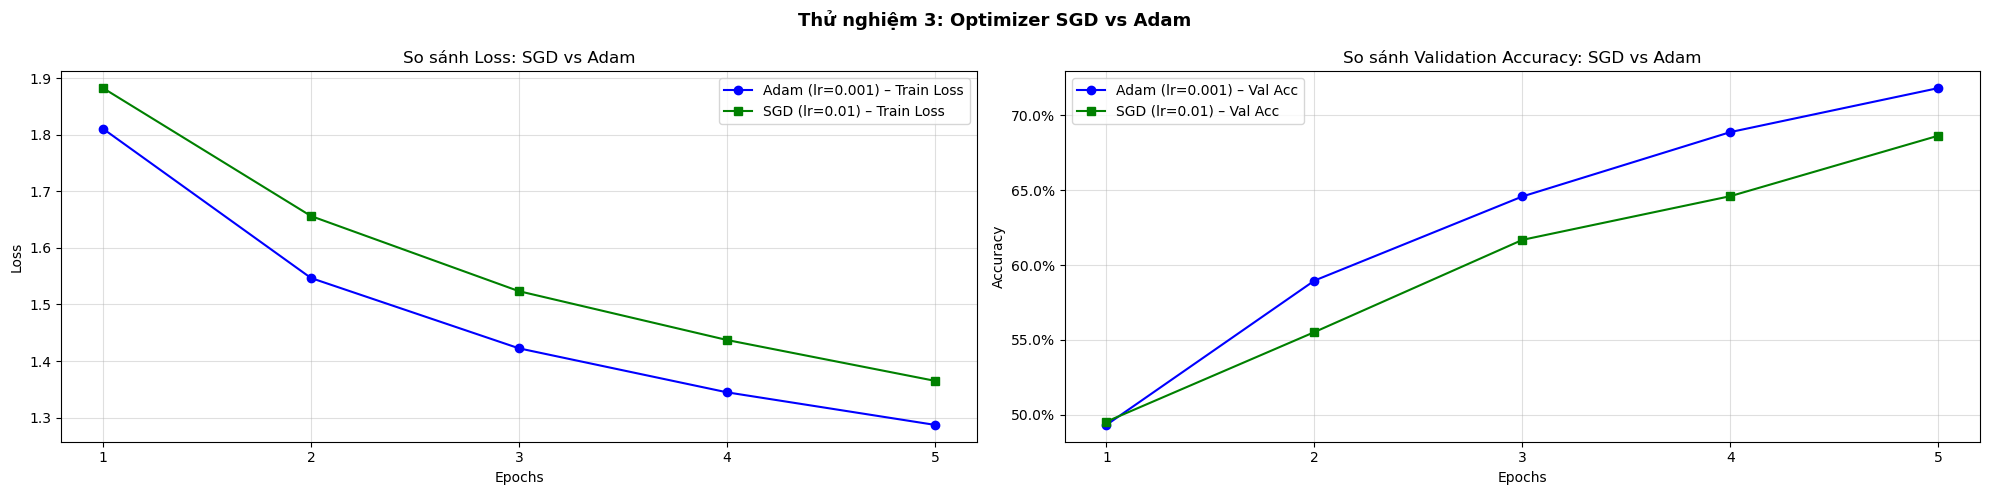


Nhận xét:
- SGD (lr=0.01): Hội tụ chậm hơn, cần nhiều epoch; nhạy cảm với learning rate
- Adam (lr=0.001): Tự điều chỉnh learning rate từng tham số → hội tụ nhanh hơn,
  ổn định hơn, accuracy cao hơn → phù hợp nhất cho bài toán này


In [ ]:
# Vẽ biểu đồ so sánh Optimizer
epochs_range = np.arange(5) + 1

plt.figure(figsize=(20, 5))

plt.subplot(121)
for i, (label, _) in enumerate([(k, None) for k in opt_results]):
    plt.plot(epochs_range, opt_results[label][0], colors[i], label=label + ' – Train Loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('So sánh Loss: SGD vs Adam')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, alpha=0.4)

plt.subplot(122)
for i, (label, _) in enumerate([(k, None) for k in opt_results]):
    plt.plot(epochs_range, opt_results[label][3], colors[i], label=label + ' – Val Acc')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.title('So sánh Validation Accuracy: SGD vs Adam')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True, alpha=0.4)

plt.suptitle('Thử nghiệm 3: Optimizer SGD vs Adam', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nNhận xét:')
print('- SGD (lr=0.01): Hội tụ chậm hơn, cần nhiều epoch; nhạy cảm với learning rate')
print('- Adam (lr=0.001): Tự điều chỉnh learning rate từng tham số → hội tụ nhanh hơn,')
print('  ổn định hơn, accuracy cao hơn → phù hợp nhất cho bài toán này')

### 8.5 Tổng kết kết quả thử nghiệm siêu tham số

In [23]:
print('=' * 70)
print('         TỔNG KẾT THỬ NGHIỆM SIÊU THAM SỐ – CNN CIFAR-10')
print('=' * 70)

print('\n[1] LEARNING RATE:')
for lr in lr_list:
    val_a = lr_results[lr][3][-1] * 100
    mark = ' ← TỐT NHẤT' if lr == 0.001 else ''
    print(f'    LR = {lr:6.4f}: Val Acc = {val_a:.2f}%{mark}')

print('\n[2] BATCH SIZE:')
for bs in bs_list:
    val_a = bs_results[bs][3][-1] * 100
    mark = ' ← TỐT NHẤT' if bs == 64 else ''
    print(f'    BS = {bs:3d}: Val Acc = {val_a:.2f}%{mark}')

print('\n[3] OPTIMIZER:')
for label in opt_results:
    val_a = opt_results[label][3][-1] * 100
    mark = ' ← TỐT NHẤT' if 'Adam' in label else ''
    print(f'    {label}: Val Acc = {val_a:.2f}%{mark}')

print('\n' + '=' * 70)
print('  CẤU HÌNH TỐI ƯU: Adam | LR=0.001 | Batch=64')
print('=' * 70)

         TỔNG KẾT THỬ NGHIỆM SIÊU THAM SỐ – CNN CIFAR-10

[1] LEARNING RATE:
    LR = 0.1000: Val Acc = 16.02%
    LR = 0.0100: Val Acc = 49.12%
    LR = 0.0010: Val Acc = 73.06% ← TỐT NHẤT

[2] BATCH SIZE:
    BS =  32: Val Acc = 71.70%
    BS =  64: Val Acc = 71.02% ← TỐT NHẤT
    BS = 128: Val Acc = 71.74%

[3] OPTIMIZER:
    Adam (lr=0.001): Val Acc = 71.82% ← TỐT NHẤT
    SGD (lr=0.01): Val Acc = 68.64%

  CẤU HÌNH TỐI ƯU: Adam | LR=0.001 | Batch=64


---
## KẾT LUẬN

### Tóm tắt kết quả
- Đã xây dựng thành công mô hình **CNN 3 Conv Block** phân loại CIFAR-10
- **Data Augmentation** (RandomCrop, HorizontalFlip, Rotation) giúp cải thiện generalization
- **BatchNorm + Dropout** giúp mô hình ổn định và tránh overfit
- Cấu hình tốt nhất: **Adam (lr=0.001), Batch Size=64**
- Mô hình CNN vượt trội so với DNN thuần (Linear layers) trên dữ liệu ảnh 2D

### Phân tích lỗi
- Cặp **cat – dog** hay nhầm nhất: hình dạng tương tự ở độ phân giải 32×32
- **automobile – truck**: đều là xe cộ, đặc trưng chung nhiều
- **ship, horse**: phân loại tốt do đặc trưng hình dạng độc đáo

### Hướng cải thiện
- Dùng kiến trúc sâu hơn: **ResNet**, **VGG** → accuracy >90%
- Áp dụng **Transfer Learning** với mô hình pretrained trên ImageNet
- Thêm augmentation mạnh hơn: **CutOut**, **MixUp**, **AutoAugment**
- Dùng **Cosine Annealing Scheduler** thay vì learning rate cố định